# Scrambling test with per-task grid + star-token control

Three conditions:
- **Original**: real ICL prompt with correct input→output pairings.
- **Scrambled**: same demos, inputs shuffled so pairings are wrong; output set is identical.
- **Star**: inputs replaced with `*`, e.g. `* → Paris\n* → Berlin\n…`. No information about which input maps to which output. The query input is still the real query.

For each condition we extract the residual at the final position at each layer and patch it into the zero-shot prompt for that query, then check accuracy.

This gives us the per-layer task-vector accuracy curve under each condition. We plot:
1. Aggregate curves (averaged across all tasks).
2. Grid of per-task curves.

## Setup

In [1]:
import sys
sys.path.insert(0, '../..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import random
import pickle

from transformer_lens import HookedTransformer
from configs import *
from utils import *

random.seed(SEED)
torch.manual_seed(SEED)
%matplotlib inline

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-10 11:56:57.742777: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained(
    MODEL_NAME, device=DEVICE,
    dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
)
model.eval()
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
d_model = model.cfg.d_model
d_head = model.cfg.d_head

with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)
tasks = load_hendel_data(HENDEL_REPO)
print(f'{n_layers}L, {n_heads}H, d={d_model}, {len(all_splits)} tasks')

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.92it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
28L, 24H, d=3072, 20 tasks


## Collect data: orig / scrambled / star

One cell, one pass. Per-task, per-layer accuracy under each of the three conditions. The aggregate curves are computed afterward from the per-task data, so there are no separate aggregate runs.

`STAR_TOKEN` is what we replace inputs with. `*` is the natural choice — it's a single token in Llama-3.2-3B and carries no semantic content. If you want to try a different placeholder, change it here.

In [ ]:
import time

N_PROMPTS = 10
RESID_FILTER = lambda name: 'resid_post' in name
STAR_TOKEN = '*'

# Per-task, per-layer accuracy
orig_per_task  = defaultdict(lambda: defaultdict(list))
scram_per_task = defaultdict(lambda: defaultdict(list))
star_per_task  = defaultdict(lambda: defaultdict(list))

t_start = time.time()

for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        eq = eval_data[p_idx % len(eval_data)]
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        # --- Build the three prompts ---
        # Original
        prompt_orig = pdata['prompt']
        
        # Scrambled: shuffle inputs while keeping outputs fixed
        inputs = [inp for inp, out in demos]
        outputs = [out for inp, out in demos]
        inputs_shuffled = inputs.copy()
        random.shuffle(inputs_shuffled)
        demos_scrambled = list(zip(inputs_shuffled, outputs))
        prompt_scram = build_icl_prompt(demos_scrambled, query_input)
        
        # Star: replace every demo's input with the star token, keep outputs and query
        demos_star = [(STAR_TOKEN, out) for inp, out in demos]
        prompt_star = build_icl_prompt(demos_star, query_input)
        
        # --- Run all three forward passes ---
        tokens_orig  = model.to_tokens(prompt_orig,  prepend_bos=True)
        tokens_scram = model.to_tokens(prompt_scram, prepend_bos=True)
        tokens_star  = model.to_tokens(prompt_star,  prepend_bos=True)
        
        with torch.no_grad():
            _, cache_orig  = model.run_with_cache(tokens_orig,  names_filter=RESID_FILTER)
            _, cache_scram = model.run_with_cache(tokens_scram, names_filter=RESID_FILTER)
            _, cache_star  = model.run_with_cache(tokens_star,  names_filter=RESID_FILTER)
        
        last_orig  = tokens_orig.shape[1]  - 1
        last_scram = tokens_scram.shape[1] - 1
        last_star  = tokens_star.shape[1]  - 1
        
        # --- Patch each layer's TV into zero-shot prompt and check accuracy ---
        for layer in range(n_layers):
            theta_orig  = cache_orig['resid_post',  layer][0, last_orig].cpu().float().numpy()
            theta_scram = cache_scram['resid_post', layer][0, last_scram].cpu().float().numpy()
            theta_star  = cache_star['resid_post',  layer][0, last_star].cpu().float().numpy()
            
            logits_orig  = eval_patched_resid(model, eq['zs_prompt'], theta_orig,  layer)
            logits_scram = eval_patched_resid(model, eq['zs_prompt'], theta_scram, layer)
            logits_star  = eval_patched_resid(model, eq['zs_prompt'], theta_star,  layer)
            
            orig_per_task[task_name][layer].append(  float(check_correct(model, logits_orig,  eq['query_output'])))
            scram_per_task[task_name][layer].append( float(check_correct(model, logits_scram, eq['query_output'])))
            star_per_task[task_name][layer].append(  float(check_correct(model, logits_star,  eq['query_output'])))
        
        del cache_orig, cache_scram, cache_star
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

: 

: 

## Save / load (optional)

In [ ]:
# Save
to_save = {
    'orig_per_task':  {t: dict(d) for t, d in orig_per_task.items()},
    'scram_per_task': {t: dict(d) for t, d in scram_per_task.items()},
    'star_per_task':  {t: dict(d) for t, d in star_per_task.items()},
}
with open('scrambling_star_results.pkl', 'wb') as f:
    pickle.dump(to_save, f)
print('Saved scrambling_star_results.pkl')

: 

In [3]:
# Load
with open('scrambling_star_results.pkl', 'rb') as f:
    loaded = pickle.load(f)
orig_per_task  = defaultdict(lambda: defaultdict(list), {t: defaultdict(list, d) for t, d in loaded['orig_per_task'].items()})
scram_per_task = defaultdict(lambda: defaultdict(list), {t: defaultdict(list, d) for t, d in loaded['scram_per_task'].items()})
star_per_task  = defaultdict(lambda: defaultdict(list), {t: defaultdict(list, d) for t, d in loaded['star_per_task'].items()})
print('Loaded')

Loaded


## Plot 1 — aggregate curves

Average across all tasks. This is the headline plot.

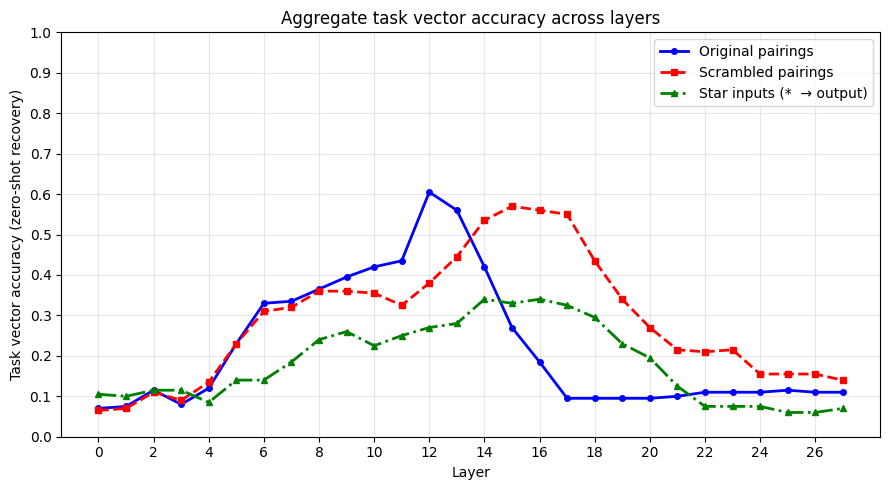

Original peak:  0.605 at layer 12
Scrambled peak: 0.570 at layer 15
Star peak:      0.340 at layer 14


In [4]:
layers = list(range(n_layers))

def aggregate_curve(per_task_dict):
    curve = []
    for l in layers:
        vals = []
        for t in per_task_dict:
            vals.extend(per_task_dict[t][l])
        curve.append(np.mean(vals) if vals else 0.0)
    return curve

orig_curve  = aggregate_curve(orig_per_task)
scram_curve = aggregate_curve(scram_per_task)
star_curve  = aggregate_curve(star_per_task)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(layers, orig_curve,  'b-o',  ms=4, lw=2, label='Original pairings')
ax.plot(layers, scram_curve, 'r--s', ms=4, lw=2, label='Scrambled pairings')
ax.plot(layers, star_curve,  'g-.^', ms=4, lw=2, label='Star inputs (*  → output)')
ax.set_xlabel('Layer')
ax.set_ylabel('Task vector accuracy (zero-shot recovery)')
ax.set_title('Aggregate task vector accuracy across layers')
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'Original peak:  {max(orig_curve):.3f} at layer {int(np.argmax(orig_curve))}')
print(f'Scrambled peak: {max(scram_curve):.3f} at layer {int(np.argmax(scram_curve))}')
print(f'Star peak:      {max(star_curve):.3f} at layer {int(np.argmax(star_curve))}')

## Plot 2 — per-task grid

Same three curves, but one subplot per task. Lets you check whether the aggregate trend holds at the task level. If, for example, some tasks lose accuracy under star but others don't, that's visible here in a way it isn't in the aggregate.

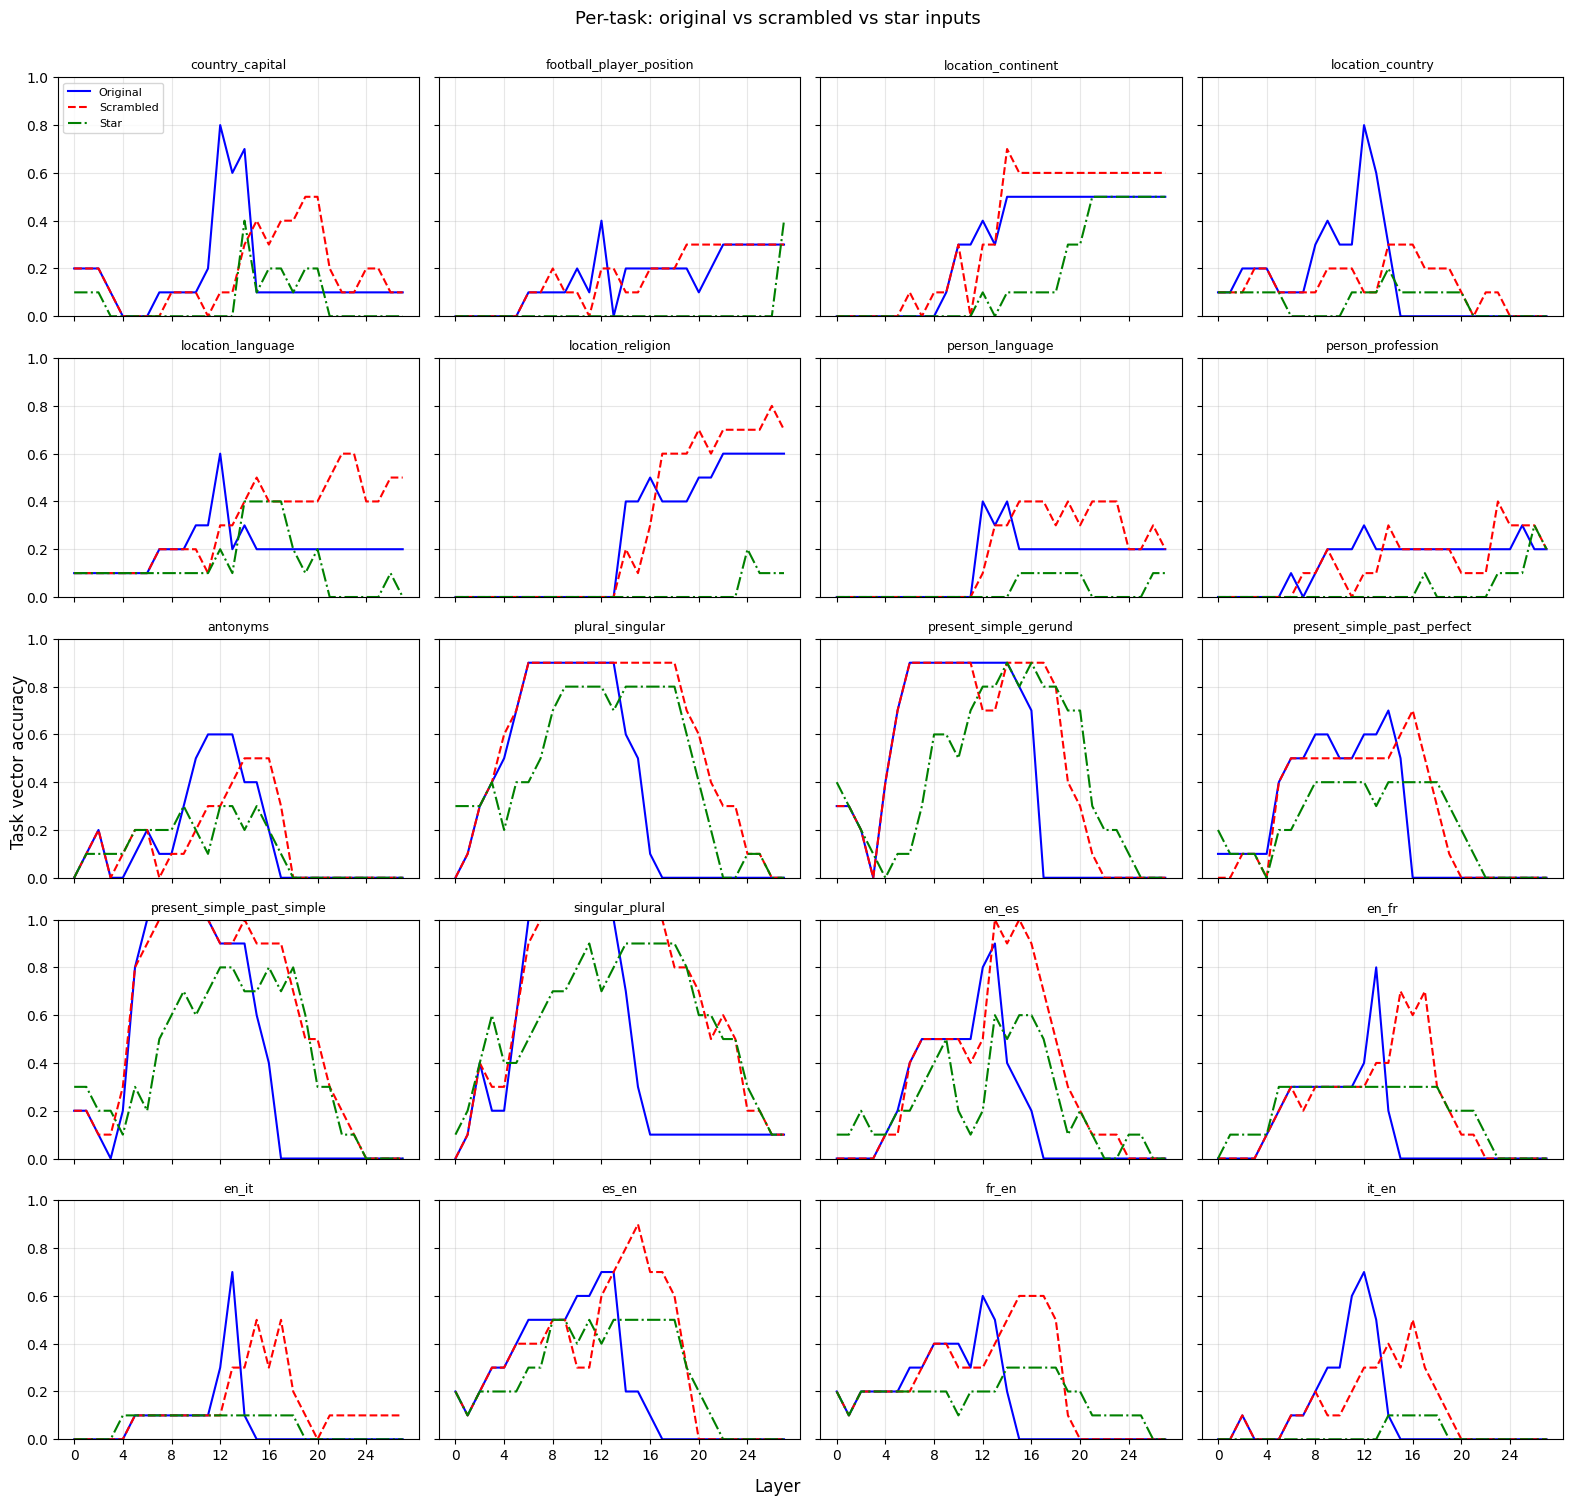

In [5]:
task_names_sorted = sorted(orig_per_task.keys())
n_tasks = len(task_names_sorted)
n_cols = 4
n_rows = (n_tasks + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, task_name in zip(axes, task_names_sorted):
    o = [np.mean(orig_per_task[task_name][l])  if orig_per_task[task_name][l]  else 0 for l in layers]
    s = [np.mean(scram_per_task[task_name][l]) if scram_per_task[task_name][l] else 0 for l in layers]
    st = [np.mean(star_per_task[task_name][l]) if star_per_task[task_name][l]  else 0 for l in layers]
    
    ax.plot(layers, o,  'b-',  lw=1.5, label='Original')
    ax.plot(layers, s,  'r--', lw=1.5, label='Scrambled')
    ax.plot(layers, st, 'g-.', lw=1.5, label='Star')
    
    short = task_name.split('/')[-1]
    ax.set_title(short, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(0, n_layers, 4))
    ax.grid(True, alpha=0.3)

# Hide unused panels
for ax in axes[n_tasks:]:
    ax.set_visible(False)

# Shared labels and legend
axes[0].legend(fontsize=8, loc='upper left')
fig.supxlabel('Layer')
fig.supylabel('Task vector accuracy')
fig.suptitle('Per-task: original vs scrambled vs star inputs', fontsize=13, y=1.001)
plt.tight_layout()
plt.show()

## Per-task summary table

Peak accuracy per task per condition, sorted by drop from orig to star (largest losses at the top).

In [6]:
print(f'{"Task":<40} {"Orig":>8} {"Scram":>8} {"Star":>8} {"Orig-Star":>11}')
print('-' * 78)
rows = []
for t in task_names_sorted:
    o  = max([np.mean(orig_per_task[t][l])  if orig_per_task[t][l]  else 0 for l in layers])
    s  = max([np.mean(scram_per_task[t][l]) if scram_per_task[t][l] else 0 for l in layers])
    st = max([np.mean(star_per_task[t][l])  if star_per_task[t][l]  else 0 for l in layers])
    rows.append((t, o, s, st))

for t, o, s, st in sorted(rows, key=lambda r: -(r[1] - r[3])):
    print(f'{t:<40} {o:>8.3f} {s:>8.3f} {st:>8.3f} {o - st:>+11.3f}')

Task                                         Orig    Scram     Star   Orig-Star
------------------------------------------------------------------------------
knowledge/location_country                  0.800    0.300    0.200      +0.600
translation/en_it                           0.700    0.500    0.100      +0.600
translation/it_en                           0.700    0.500    0.100      +0.600
translation/en_fr                           0.800    0.700    0.300      +0.500
knowledge/country_capital                   0.800    0.500    0.400      +0.400
knowledge/location_religion                 0.600    0.800    0.200      +0.400
knowledge/person_language                   0.400    0.400    0.100      +0.300
translation/en_es                           0.900    1.000    0.600      +0.300
linguistic/antonyms                         0.600    0.500    0.300      +0.300
translation/fr_en                           0.600    0.600    0.300      +0.300
linguistic/present_simple_past_perfect   